# Multi-Agent RL: Cooperative and Competitive Agents

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand multi-agent RL concepts (cooperation, competition, non-stationarity)
- Implement a competitive two-agent grid environment
- Train competitive agents with independent Q-learning
- Understand, at concept level, how cooperative training and other MARL approaches differ (training them is beyond this lesson's scope)

## 🔗 Where this fits

**Builds on:** Course 02 (AIAT 112) — Unit 3, lesson 04 "Markov Decision Processes (MDPs) and Value Iteration" — an MDP assumes the transition rule is *stationary*; put a second learning agent inside the environment and that assumption breaks, which is the entire difficulty of this lesson.

---

## Official Structure Reference

This notebook covers practical activities from **Course 09, Unit 5**:
- Implementing multi-agent RL environments and training cooperative/competitive agents

---

## Introduction

**Multi-agent RL** involves multiple agents learning and interacting in the same environment, either cooperatively (shared goals) or competitively (conflicting goals).

## Lesson Brief

This lesson introduces environments where more than one agent is learning at the same time.

Students will see how cooperation and competition create new difficulties that do not exist in single-agent RL.

Why this matters: many real systems involve multiple decision-makers, not only one isolated learner.

This lesson helps students understand why multi-agent environments feel less stable.

### If Python feels hard right now

- Run code cells **from top to bottom** the first time; later you can re-run one cell after you change it.
- In code cells, a line that starts with `# ` (hash + space) is a **hint for the very next line**—read the hint, then read the code under it.
- You do **not** need to memorize syntax. Follow the story: *what is stored*, *what gets printed*, and *what the plot is trying to show*.
- If something errors, read the last line of the red traceback first—it usually names the problem in plain language.


## 🌍 Real case: 45,000 years of Dota, and agents that learned to surf on boxes

**The result.** On **13 April 2019**, OpenAI Five beat OG, the reigning Dota 2 world champions —
the first time an AI system defeated world champions at an esports game (Berner et al., "Dota 2 with
Large Scale Deep Reinforcement Learning", 2019). Five agents, one team, learning together, against a
human team doing the same.

**The price.** OpenAI's write-up puts it at about **45,000 years of simulated self-play over ten
months of real time** — roughly 250 years of game experience per day. Not a metaphor: that is what it
cost to reach the top of one game with a fixed rule set and a perfect simulator.

**The surprise.** Baker et al. ("Emergent Tool Use From Multi-Agent Autocurricula", ICLR 2020) ran
hide-and-seek between two teams of agents and watched six distinct strategy phases emerge from
competition alone — running, fort-building with boxes, ramp use, ramp defence, and then two that
nobody designed: the seekers learned to stand on a box and **surf** it across the map without touching
the ground, exploiting the physics engine, and the hiders learned to lock the boxes down to stop them.
The paper's own summary is the lesson: the agents "were very skilled at exploiting small inaccuracies
in the design of the environment".

**What goes wrong without this.** In single-agent RL the environment is fixed while you learn. Here it
is not: the other agent is learning too, so the problem you solved yesterday is a different problem
today. That is *non-stationarity*, and it removes the convergence guarantees every algorithm in Units
1 and 2 relies on. The run below shows it directly — two independent Q-learners, each treating the
other as part of a world that will not sit still.


## Recommended YouTube Video

To reinforce this lesson, watch **Machine Learning with Phil - "Can AI Learn to Cooperate? Multi Agent Deep Deterministic Policy Gradients (MADDPG) in PyTorch"**:
[Watch on YouTube](https://www.youtube.com/watch?v=tZTQ6S9PfkE)

Why this pick:
- focused treatment of cooperative and competitive multi-agent learning.
- Explains why multi-agent settings are harder than single-agent RL.
- Helpful for students seeing centralized training and decentralized behavior ideas for the first time.

## Student Support Pack

Use this section as a checkpoint before and after the main code cells so the idea stays clearer than the syntax.

### Key Terms
- Cooperative setting: agents help each other.
- Competitive setting: one agent can hurt another.
- Coordination: aligning actions.
- Non-stationarity: the world changes because other agents act too.
- Credit assignment: deciding which agent deserves reward or blame.

### Quick Check
- How is multi-agent RL different from single-agent RL?
- What changes between cooperation and competition?
- Why can the environment feel unstable to one agent?
- Why is assigning credit harder when many agents contribute?

### Common Mistakes
- Assuming other agents are fixed.
- Ignoring coordination failures.
- Treating cooperation and competition as small details.
- Forgetting that learning becomes harder because each agent changes the training environment for the others.


## Why Multi-Agent RL Feels Harder Than Single-Agent RL

In single-agent RL, the environment may already be difficult, but at least the agent is usually not competing with other changing learners.

### The key difficulty

In multi-agent RL, each learner changes the world seen by the others.
That means the environment can feel non-stationary even if the external rules stay the same.

### Cooperation versus competition

- In **cooperation**, the difficulty is often coordination and shared credit.
- In **competition**, the difficulty is often adaptation, strategy, and opponent response.

### Teaching takeaway

Students should not think multi-agent RL is only "single-agent RL plus more people."
It changes the nature of the learning problem itself.

## Inputs and Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---


### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


In [1]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np

# Show text or numbers in the cell output area under the code.
print("✅ Libraries imported!")
# Show text or numbers in the cell output area under the code.
print("\nMulti-Agent RL: Cooperative and Competitive Agents")
# Show text or numbers in the cell output area under the code.
print("=" * 60)

# Show text or numbers in the cell output area under the code.
print("\nMulti-Agent RL Types:")
# Show text or numbers in the cell output area under the code.
print("  - Cooperative: Agents share rewards, work toward common goal")
# Show text or numbers in the cell output area under the code.
print("  - Competitive: Agents have conflicting goals (zero-sum)")
# Show text or numbers in the cell output area under the code.
print("  - Mixed: Combination of cooperation and competition")

# Show text or numbers in the cell output area under the code.
print("\nKey Challenges:")
# Show text or numbers in the cell output area under the code.
print("  - Non-stationary environment (other agents learn)")
# Show text or numbers in the cell output area under the code.
print("  - Credit assignment (who gets credit)")
# Show text or numbers in the cell output area under the code.
print("  - Coordination (communicating/coordinating actions)")
# Show text or numbers in the cell output area under the code.
print("  - Scalability (many agents)")

# Show text or numbers in the cell output area under the code.
print("\n✅ Multi-agent RL concepts understood!")


✅ Libraries imported!

Multi-Agent RL: Cooperative and Competitive Agents

Multi-Agent RL Types:
  - Cooperative: Agents share rewards, work toward common goal
  - Competitive: Agents have conflicting goals (zero-sum)
  - Mixed: Combination of cooperation and competition

Key Challenges:
  - Non-stationary environment (other agents learn)
  - Credit assignment (who gets credit)
  - Coordination (communicating/coordinating actions)
  - Scalability (many agents)

✅ Multi-agent RL concepts understood!


## 🌍 Industry-Motivated Worked Example — Competitive Multi-Agent with Independent Q-Learning

> **What is real here and what is not.** The industry uses below are real. The two-agent grid
> is a model we wrote. Gymnasium ships single-agent environments only, so there is no standard
> installed benchmark for this lesson — multi-agent work uses separate libraries such as
> PettingZoo. The randomness in the cell is exploration, nothing else.

**Industry context:**
- Waymo simulates thousands of autonomous vehicles (agents) sharing the same road
- Google DeepMind's AlphaStar has 10 agents competing simultaneously in StarCraft II

We simulate a simple **2-agent grid competition** where two agents learn to navigate to goals while avoiding each other.

### Step Guide

**What this cell does:** Import libraries and set small global constants for the lesson.

**How to read it (weak Python OK):** Read the `#` hint lines in the next cell top-to-bottom, run it once, then look at the output before diving into implementation details.

**What to expect in the output:** Printed numbers, small tables, logs, or figures tied to the current section header.

**If you feel lost:** Skim only the `#` lines in the next cell, run it once, then re-read the same hints with the output visible.


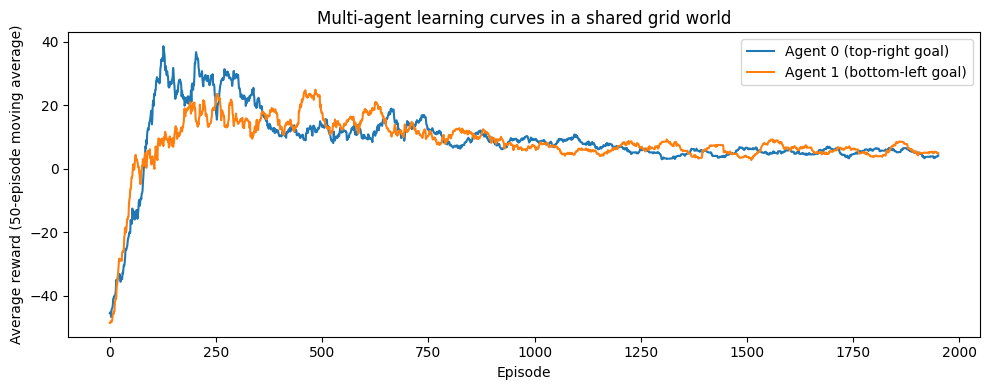


Final average rewards -> Agent 0: 4.6, Agent 1: 4.7

Teaching point:
Each agent learns while the other agent is also changing, which makes the
environment non-stationary from any single agent's perspective.


In [2]:
# Setup step: import the libraries that will carry the math, plotting, and learning logic.
# Reading the imports first helps students see which tools each later cell depends on.

# Load a library so you can use its ready-made functions and types below.
import numpy as np
# Load a library so you can use its ready-made functions and types below.
import matplotlib.pyplot as plt

# Use NumPy for fast numeric arrays and math on grids of numbers.
np.random.seed(42)
# Save a value in a name so the next lines can read it.
GRID = 5
# Another assignment—same idea: store a value for the lines below.
N_ACTIONS = 4
# Another assignment—same idea: store a value for the lines below.
DELTAS = [(-1, 0), (1, 0), (0, -1), (0, 1)]


# Function `state_to_idx` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: r, c.
def state_to_idx(r, c):
    # Send a value back to whoever called this function.
    return r * GRID + c


# Function `step_agent` (what it does): no docstring in this cell; read the indented body for the exact logic. Parameter names: pos, action.
def step_agent(pos, action):
    # Save a value in a name so the next lines can read it.
    dr, dc = DELTAS[action]
    # Send a value back to whoever called this function.
    return (max(0, min(GRID - 1, pos[0] + dr)), max(0, min(GRID - 1, pos[1] + dc)))


# Save a value in a name so the next lines can read it.
GOALS = [(0, GRID - 1), (GRID - 1, 0)]
# Another assignment—same idea: store a value for the lines below.
Q = [np.zeros((GRID * GRID, N_ACTIONS)) for _ in range(2)]
# Another assignment—same idea: store a value for the lines below.
alpha = 0.1
# Another assignment—same idea: store a value for the lines below.
gamma = 0.95
# Another assignment—same idea: store a value for the lines below.
eps = 1.0
# Another assignment—same idea: store a value for the lines below.
eps_decay = 0.998
# Unpack the one-step model output from transition(state, action).
rewards_hist = [[], []]

# Start a loop: repeat the indented block once per item in the sequence.
for ep in range(2000):
    # Save a value in a name so the next lines can read it.
    pos = [(GRID - 1, 0), (0, GRID - 1)]
    # Another assignment—same idea: store a value for the lines below.
    ep_r = [0, 0]
    # Start a loop: repeat the indented block once per item in the sequence.
    for _ in range(50):
        # Save a value in a name so the next lines can read it.
        actions = []
        # Start a loop: repeat the indented block once per item in the sequence.
        for i in range(2):
            # Save a value in a name so the next lines can read it.
            s = state_to_idx(*pos[i])
            # Another assignment—same idea: store a value for the lines below.
            a = np.random.randint(N_ACTIONS) if np.random.rand() < eps else Q[i][s].argmax()
            # Add one new item to the end of a list (the list grows in place).
            actions.append(a)
        # Save a value in a name so the next lines can read it.
        new_pos = [step_agent(pos[i], actions[i]) for i in range(2)]
        # Start a loop: repeat the indented block once per item in the sequence.
        for i in range(2):
            # Save a value in a name so the next lines can read it.
            s = state_to_idx(*pos[i])
            # Another assignment—same idea: store a value for the lines below.
            s2 = state_to_idx(*new_pos[i])
            # Another assignment—same idea: store a value for the lines below.
            r = 10 if new_pos[i] == GOALS[i] else -1
            # Another assignment—same idea: store a value for the lines below.
            r -= 5 if new_pos[0] == new_pos[1] else 0
            # Another assignment—same idea: store a value for the lines below.
            Q[i][s, actions[i]] += alpha * (r + gamma * Q[i][s2].max() - Q[i][s, actions[i]])
            # Another assignment—same idea: store a value for the lines below.
            ep_r[i] += r
        # Another assignment—same idea: store a value for the lines below.
        pos = new_pos
        # If the condition is True, run the indented block under this line.
        if pos[0] == GOALS[0] and pos[1] == GOALS[1]:
            # Stop the loop completely and continue after the loop block.
            break
    # Start a loop: repeat the indented block once per item in the sequence.
    for i in range(2):
        # Add one new item to the end of a list (the list grows in place).
        rewards_hist[i].append(ep_r[i])
    # Save a value in a name so the next lines can read it.
    eps = max(eps * eps_decay, 0.05)

# Another assignment—same idea: store a value for the lines below.
ma0 = np.convolve(rewards_hist[0], np.ones(50) / 50, "valid")
# Another assignment—same idea: store a value for the lines below.
ma1 = np.convolve(rewards_hist[1], np.ones(50) / 50, "valid")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.figure(figsize=(10, 4))
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(ma0, label="Agent 0 (top-right goal)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.plot(ma1, label="Agent 1 (bottom-left goal)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.title("Multi-agent learning curves in a shared grid world")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.xlabel("Episode")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.ylabel("Average reward (50-episode moving average)")
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.legend()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.tight_layout()
# Use pyplot to create or tweak a figure (plot, labels, show, etc.).
plt.show()

# Show text or numbers in the cell output area under the code.
print(
    # Build text with {…} holes filled in by variables (an f-string).
    f"\nFinal average rewards -> Agent 0: {np.mean(rewards_hist[0][-100:]):.1f}, "
    # Build text with {…} holes filled in by variables (an f-string).
    f"Agent 1: {np.mean(rewards_hist[1][-100:]):.1f}"
# Close the parentheses opened earlier (end this function call / grouping).
)
# Show text or numbers in the cell output area under the code.
print("\nTeaching point:")
# Show text or numbers in the cell output area under the code.
print("Each agent learns while the other agent is also changing, which makes the")
# Show text or numbers in the cell output area under the code.
print("environment non-stationary from any single agent's perspective.")


### 👁️ Read the figure

- **Two curves, one per agent, both measured in the same run.** The x-axis is the training
  episode; the y-axis is that agent's own reward, smoothed over 50 episodes. Agent 0 is heading
  for the top-right tile, Agent 1 for the bottom-left, and they share one 5x5 grid.
- **Both curves climb steeply out of about −48.** That is the easy part: each agent is learning
  where its own goal is, and at first the other agent is still wandering randomly and barely gets
  in the way.
- **Then look at what happens after the peaks — this is the whole lesson.** Agent 0 tops out near
  +38 around episode 130 and Agent 1 near +25 a little later, and then **both curves fall back and
  settle around +5**. Neither agent got worse at navigating. What changed is the *other agent*: as
  each one starts taking its own shortest route, the two routes cross, and the −5 collision penalty
  starts landing on both of them.
- **The permanent wobble after episode 500 is not noise to be smoothed away.** It is two learners
  taking turns adapting to each other. A single-agent curve on a fixed environment flattens out;
  this one cannot, because the environment each agent faces contains the other agent.

**What it proves:** the "non-stationary environment" line in the summary, drawn rather than
asserted. From Agent 0's point of view the rules of the world kept changing — not because anyone
changed the grid, but because the other player was learning at the same time. That is the single
thing that makes multi-agent RL harder than running two separate Q-learners.

In [3]:
# References (shown with Markdown inside a Python cell — avoids SyntaxError if a Markdown block is run as code.)
# Seminal papers first, then recent landmarks and surveys; linked entries were checked against their arXiv/publisher pages.
from IPython.display import Markdown, display

display(Markdown(r"""## 📚 References

1. Littman, M. L. (1994). *Markov Games as a Framework for Multi-Agent Reinforcement Learning*. ICML.
2. Lowe, R., Wu, Y., Tamar, A. et al. (2017). *Multi-Agent Actor-Critic for Mixed Cooperative-Competitive Environments* (MADDPG). NeurIPS. <https://arxiv.org/abs/1706.02275>
3. Vinyals, O., Babuschkin, I., Czarnecki, W. M. et al. (2019). *Grandmaster Level in StarCraft II Using Multi-Agent Reinforcement Learning* (AlphaStar). Nature. <https://www.nature.com/articles/s41586-019-1724-z>
4. Zhang, K., Yang, Z. & Başar, T. (2021). *Multi-Agent Reinforcement Learning: A Selective Overview of Theories and Algorithms*. Handbook of Reinforcement Learning and Control, Springer. <https://arxiv.org/abs/1911.10635>
5. Luo, X., Zhang, Y., He, Z. et al. (2025). *Agent Lightning: Train ANY AI Agents with Reinforcement Learning* — RL training decoupled from the agent implementation, with credit assigned to individual steps of a trace. arXiv:2508.03680. <https://arxiv.org/abs/2508.03680>
6. Feng, L., Zheng, L., He, S., Zhang, F. & An, B. (2026). *Dr. MAS: Stable Reinforcement Learning for Multi-Agent LLM Systems* — per-agent advantage normalisation as a fix for multi-agent training instability. arXiv:2602.08847. <https://arxiv.org/abs/2602.08847>
"""))

## 📚 References

1. Littman, M. L. (1994). *Markov Games as a Framework for Multi-Agent Reinforcement Learning*. ICML.
2. Lowe, R., Wu, Y., Tamar, A. et al. (2017). *Multi-Agent Actor-Critic for Mixed Cooperative-Competitive Environments* (MADDPG). NeurIPS. <https://arxiv.org/abs/1706.02275>
3. Vinyals, O., Babuschkin, I., Czarnecki, W. M. et al. (2019). *Grandmaster Level in StarCraft II Using Multi-Agent Reinforcement Learning* (AlphaStar). Nature. <https://www.nature.com/articles/s41586-019-1724-z>
4. Zhang, K., Yang, Z. & Başar, T. (2021). *Multi-Agent Reinforcement Learning: A Selective Overview of Theories and Algorithms*. Handbook of Reinforcement Learning and Control, Springer. <https://arxiv.org/abs/1911.10635>
5. Luo, X., Zhang, Y., He, Z. et al. (2025). *Agent Lightning: Train ANY AI Agents with Reinforcement Learning* — RL training decoupled from the agent implementation, with credit assigned to individual steps of a trace. arXiv:2508.03680. <https://arxiv.org/abs/2508.03680>
6. Feng, L., Zheng, L., He, S., Zhang, F. & An, B. (2026). *Dr. MAS: Stable Reinforcement Learning for Multi-Agent LLM Systems* — per-agent advantage normalisation as a fix for multi-agent training instability. arXiv:2602.08847. <https://arxiv.org/abs/2602.08847>


## 💬 Discuss

The measured result: after training, **Agent 0 averaged 4.6 and Agent 1 averaged 4.7** — essentially
level. Argue these out.

1. Two competitive learners ending level could mean they found a good mutual equilibrium, or that both
   are mediocre and cancel out, or that they are cycling — each briefly beating the other forever.
   Those are three very different systems and the two numbers cannot distinguish them. What single
   extra measurement would separate them? Design it precisely enough to code.
2. In single-agent RL a rising reward curve is evidence of learning. In self-play, both agents get
   better and the *relative* score can stay flat. So how do you demonstrate progress at all? (AlphaStar
   and OpenAI Five both had an answer; what would yours be for a two-agent system with no external
   opponent?)
3. Hide-and-seek's box surfing was reward hacking discovered by *competition*, not by a single agent
   gaming a proxy. Does adding more agents make specification gaming more likely or less? Argue it,
   then say what you would do differently in a multi-agent design review as a result.


## 📝 Summary

You explored **Multi-Agent Reinforcement Learning (MARL)** where multiple agents interact in shared environments. Independent Q-Learning is simple but can be unstable. Real applications: autonomous vehicles at intersections, trading algorithms, and multiplayer game AI.

## ⚠️ Where this breaks

**The assumption that has to hold:** every algorithm in Units 1–3 assumes a stationary environment.
The moment another learning agent is in it, that assumption is false — and independent Q-learning,
which is what runs below, simply ignores the problem.

- **No convergence guarantee survives.** Each agent's environment includes the other's policy, which
  changes every episode. The Q-learning proof requires fixed transition probabilities. What you get
  instead may converge, may cycle, or may oscillate indefinitely, and the reward curve looks similar
  in all three cases.
- **Credit assignment across agents is a separate unsolved problem.** In the cooperative case, a team
  reward tells no individual agent what *it* did well. This is why methods like value decomposition
  and centralised-critic training exist; independent learners just guess.
- **Self-play sample costs are the largest in the field.** 45,000 years for one game with a perfect
  simulator. If your multi-agent problem has no simulator — a market, a logistics network with real
  vehicles, a negotiation — that number is the reason the project stops.
- **Emergent exploits scale with the number of agents.** Competition is an extremely effective search
  for holes in your environment. Box surfing was not in anyone's plan. Assume your simulator has a
  bug your agents will find, and budget time to go looking for it *before* they do.
- **Cheaper alternative:** if the agents are genuinely cooperative and you can observe everything, a
  single centralised controller over the joint action space avoids all of the above — it is one agent
  again, with a bigger action set. And if the interaction is simple and known (an auction, a traffic
  intersection, a queue), a mechanism or protocol designed by hand is auditable, provable and does not
  need 45,000 years of anything.


## Closing Takeaway

**Teaching takeaway:** Multi-agent RL becomes harder because each agent changes the environment seen by the others, creating non-stationarity.

**If students remember one idea:** When many learners act together, the world changes not only because of the environment but because the other learners keep adapting too.

**Quick check before moving on:**
- Can you explain why training becomes less stable when other agents are also learning?
- Can you describe the difference between cooperative and competitive multi-agent settings?

**Bridge to the next step:** Next, students will see how hierarchical structure can simplify long or complex tasks even in single-agent settings.

**For weaker coders:** After you run the important cells, write one sentence: *what number or plot changed, and does that match what the lesson said should happen?* If not, re-read only the `#` hint lines in that cell—not every line of Python.


## 🔭 State of the field (2026)

Most multi-agent systems being built in 2026 are teams of language-model agents — a planner that delegates,
workers that call tools, a reviewer that aggregates — and training them with RL is now an engineering problem
rather than a research curiosity. The two difficulties you just watched are precisely the ones that came back.
**Non-stationarity:** each agent's environment contains the others, so updates computed against one shared
baseline destabilise, and a 2026 answer is to normalise each agent's advantage using that agent's own reward
statistics instead (Feng et al. 2026). **Credit assignment:** a team-level reward still tells no individual
agent what *it* did well, which is why current frameworks keep the trainer separate from the agent code and
attribute reward to individual steps of the interaction trace (Luo et al. 2025).

Independent Q-learning on a 5x5 grid is not obsolete here — it is the cheapest place in the whole diploma to
*see* the failure mode rather than read about it, and it is the baseline that centralised-critic and
value-decomposition methods are measured against. The curve above that climbs, peaks and settles back to about
+5 is the same non-stationarity those 2026 papers are engineering around, on a scale where you can check every
number yourself.

- Luo, X., Zhang, Y., He, Z. et al. (2025). *Agent Lightning: Train ANY AI Agents with Reinforcement Learning*. arXiv:2508.03680. <https://arxiv.org/abs/2508.03680>
- Feng, L., Zheng, L., He, S., Zhang, F. & An, B. (2026). *Dr. MAS: Stable Reinforcement Learning for Multi-Agent LLM Systems*. arXiv:2602.08847. <https://arxiv.org/abs/2602.08847>

*Context, not curriculum. The examinable content of this lesson is unchanged; this box says where the field went next.*

## Motion recap (optional)

**Why this cell exists:** many RL ideas are easiest to sanity-check when you can **watch time unfold** — a state changes because an action was taken, then a reward signal arrives.

**FrozenLake here is a shared toy picture** (not the “whole story” of every method in this notebook):
- Treat it as a **concrete instance** of the vocabulary you already used: **state** = which tile, **action** = move direction, **reward** = goal / hole / step, **episode** = from start until stop.

**Map this picture to your lesson (pick what fits):**
- **MDPs / value iteration / DP ideas:** ask what a “good tile” should be worth *on the way* to the goal, and what a hole implies for long-horizon returns.
- **Policy evaluation / Monte Carlo / TD / Q-learning / SARSA:** relate the moves you see to **estimated values or Q(s,a)** and to the **backup** idea you implemented above.
- **Exploration vs exploitation / UCB / tuning ε:** random moves are a deliberate exaggeration — compare **wide wandering** vs a mostly greedy path, and connect that to the exploration rule you studied in this unit.
- **Deep RL / training at scale:** use this as a **minimal loop** (observe → act → reward → learn) while remembering real applications change the **observation**, not the basic cycle.

The policy in the next cell is **random on purpose** so the GIF/slider foreground **transitions**, not a claim that this notebook’s full method is already optimal on this map.

### Why the agent may never reach the gift (goal tile `G`)
The code uses **uniform random actions**. That is **not** trying to “solve” FrozenLake or show a hero run to the goal. The point is to show **typical transitions**: safe tiles, edges, sometimes holes, sometimes lucky progress. **Not reaching `G` is expected** and still useful — read the **sequence** (state → action → next state → reward), not “did it win in 10 seconds?”

### Quick student check (about 60 seconds)
- Scroll to **one core code cell above** that carries the main idea of this lesson (policy update, backup, ε-rule, training step, …).
- In one sentence, name **one symbol or variable** from that cell that lines up with **state**, **action**, or **reward** in the FrozenLake frames.
- If you cannot name a match yet, re-run the main lesson cells once, then return here — the GIF is a **mirror** for vocabulary, not a replacement for the definitions.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


Motion recap | return=0.0 | frames=23 | term=True | trunc=False


objc[67325]: Class SDL_RumbleMotor is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10ffdc138) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11051c9c8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[67325]: Class SDL_RumbleContext is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10ffdc188) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11051ca18). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[67325]: Class SDLApplication is implemented in both /opt/homebrew/Cellar/sdl2/2.32.10/lib/libSDL2-2.0.0.dylib (0x10ffdbc88) and /Users/abdullah/Downloads/AI Diploma/.venv/lib/python3.14/site-packages/pygame/.dylibs/libSDL2-2.0.0.dylib (0x11051ca68). T

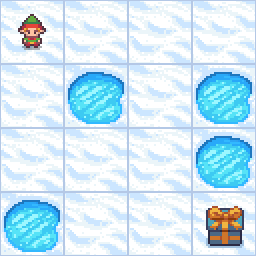

In [4]:
# MOTION_RECAP_COURSE09 — shared optional visual (FrozenLake GIF + step slider).

%pip install pillow ipywidgets -q

import pathlib
import sys

import numpy as np

# Walk up the folder tree to find the Course 09 root, where the shared course09_step_viz.py helper lives.
for _d in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]:
    if (_d / "course09_step_viz.py").exists():
        _course09 = _d
        break
else:
    raise FileNotFoundError(
        "Could not find course09_step_viz.py — open this notebook from inside Course 09 "
        "(normal Jupyter / Cursor layout) so parent folders include the Course 09 root."
    )

# Put the Course 09 root on Python's import path so the shared helper can be imported from any unit folder.
if str(_course09) not in sys.path:
    sys.path.insert(0, str(_course09))

import gymnasium as gym
# cs9viz turns recorded environment frames into an animated GIF plus a step-by-step slider.
import course09_step_viz as cs9viz


# Random policy: pick any action with equal chance — the 'no learning yet' baseline behaviour.
def _random_policy(obs, step):
    return int(np.random.randint(0, 4))


# Create the environment in rgb_array mode so every step can be captured as an image frame.
env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False, render_mode="rgb_array")
# Play one episode with this policy, saving one frame per step (a fixed seed keeps the run reproducible).
frames, total_r, terminated, truncated = cs9viz.collect_rollout_frames(
    env, _random_policy, max_steps=48, seed=42
)
env.close()
print(
    f"Motion recap | return={total_r:.1f} | frames={len(frames)} | term={terminated} | trunc={truncated}"
)
# Replay the episode as an animation, then as a slider you can scrub step by step — motion connects the numbers to behaviour.
cs9viz.display_gif(frames, duration_ms=110)
cs9viz.display_step_slider(frames, title="FrozenLake — timestep")


## Did you understand? (about 2 minutes)

<!-- STUDENT_SELF_CHECK_COURSE09 -->

Answer **without scrolling** first. Then scroll only to compare with the notebook.

1. **One sentence:** What is the *single main idea* you are supposed to carry to the next lesson?
2. **Trace one step:** Pick one moment from this notebook (a number you printed, a plot, a table, or a GIF/slider frame). Write **state → action → reward → next state** in your own words — even if your “state” is a vector or a tile index.
3. **One honest confusion:** Write one question you still have. That question is what you should bring to class, study group, or office hours.

**If any answer is blank:** run the notebook again from the top **slowly** (run one cell → read the output → only then run the next).

**Remember:** a clean run means the code worked — it does **not** automatically mean every idea clicked. Confusion is normal until you can do steps 1–2 in plain language.
